# 04 — Evaluace modelu

**Cíl:** Pořádně vyhodnotit natrénovaný model — číselné metriky, aerodynamický
koeficient vztlaku (Cl), a out-of-distribution experiment (co se stane s ne-airfoily).

**Co tu spočítáme:**
1. Volume metriky (MAE, RMSE, R² na celém poli)
2. Surface metriky (tlak na povrchu profilu)
3. **Cl** (lift koeficient) z gridu — ground truth vs predikce
4. **Spearman korelace** — řadí model profily podle vztlaku správně?
5. Error analýza — kde model selhává
6. **OOD experiment** — trojúhelník/čtverec → model dělá nesmysl

**Pozn. k metodice Cl:** Počítáme Cl integrací tlaku kolem povrchu profilu, přímo
z 128×128 gridu. Stejný výpočet aplikujeme na ground truth i predikci → férové
srovnání. Absolutní hodnoty nejsou tak přesné jako z původního jemného meshe, ale
pro srovnání model vs realita to stačí. **Cd záměrně neřešíme** — závisí silně na
wall shear stress (gradienty rychlosti u povrchu), které hrubý grid nezachytí přesně.
To je známé omezení metody (diskutováno na konci).

---

## 1. Importy a načtení modelu

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

DATA_PATH = "../data/processed.npz"
MODEL_PATH = "../models/best_model.pth"

def build_unet():
    return smp.Unet(encoder_name="resnet34", encoder_weights=None,
                    in_channels=3, classes=3)

model = build_unet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model nacten.")

Device: cuda
Model nacten.


## 2. Načtení dat + denormalizační statistiky

Načteme data a hlavně statistiky (`Y_mean`, `Y_std`), abychom mohli predikce
převést zpátky do fyzikálních jednotek (Pa, m/s).

In [2]:
data = np.load(DATA_PATH)
X = data["X"]            # (800, 3, 128, 128) normalizovane vstupy
Y = data["Y"]            # (800, 3, 128, 128) normalizovane vystupy
X_mean, X_std = data["X_mean"], data["X_std"]
Y_mean, Y_std = data["Y_mean"], data["Y_std"]

print(f"X: {X.shape}, Y: {Y.shape}")
print("\nDenormalizacni statistiky (vystup):")
for i, name in enumerate(["tlak", "u", "v"]):
    print(f"  {name}: mean={Y_mean[0,i,0,0]:.2f}, std={Y_std[0,i,0,0]:.2f}")

# Pomocne funkce pro (de)normalizaci
def denorm_Y(arr_norm):
    """Z normalizovaneho na fyzikalni jednotky. arr_norm: (..., 3, H, W)"""
    return arr_norm * Y_std + Y_mean

def denorm_X(arr_norm):
    return arr_norm * X_std + X_mean

X: (800, 3, 128, 128), Y: (800, 3, 128, 128)

Denormalizacni statistiky (vystup):
  tlak: mean=-24.03, std=339.27
  u: mean=61.26, std=18.92
  v: mean=4.33, std=6.78


## 3. Predikce na celém datasetu

Pustíme model na všechny vzorky a uložíme predikce. Děláme to v dávkách (memory-safe).

In [3]:
from torch.utils.data import DataLoader, TensorDataset

ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
loader = DataLoader(ds, batch_size=16, shuffle=False)

all_preds = []
all_targets = []
with torch.no_grad():
    for xb, yb in loader:
        pred = model(xb.to(device)).cpu().numpy()
        all_preds.append(pred)
        all_targets.append(yb.numpy())

preds = np.concatenate(all_preds)        # (800, 3, 128, 128) normalizovane
targets = np.concatenate(all_targets)
print(f"Predikce: {preds.shape}")

# Denormalizace do fyzikalnich jednotek
preds_phys = denorm_Y(preds)
targets_phys = denorm_Y(targets)
print("Denormalizovano do Pa / m/s.")

Predikce: (800, 3, 128, 128)
Denormalizovano do Pa / m/s.


## 4. Volume metriky (MAE, RMSE, R²)

Číselné metriky na celém poli, pro každý kanál zvlášť. **R² blízko 1.0 = výborné.**

Pozn.: Počítáme na fyzikálních jednotkách. R² (koeficient determinace) říká jakou
část variance dat model vysvětluje.

In [4]:
def compute_metrics(pred, target):
    """MAE, RMSE, R2 pro jedno pole (flattened)."""
    p, t = pred.ravel(), target.ravel()
    mae = np.mean(np.abs(p - t))
    rmse = np.sqrt(np.mean((p - t)**2))
    ss_res = np.sum((t - p)**2)
    ss_tot = np.sum((t - t.mean())**2)
    r2 = 1 - ss_res / ss_tot
    return mae, rmse, r2

print(f"{'Kanal':<10}{'MAE':>12}{'RMSE':>12}{'R2':>10}")
print("-" * 44)
for i, (name, unit) in enumerate([("tlak", "Pa"), ("u", "m/s"), ("v", "m/s")]):
    mae, rmse, r2 = compute_metrics(preds_phys[:, i], targets_phys[:, i])
    print(f"{name:<10}{mae:>10.2f} {unit:<3}{rmse:>9.2f}    {r2:>8.4f}")

Kanal              MAE        RMSE        R2
--------------------------------------------
tlak           21.28 Pa     40.93      0.9854
u               1.39 m/s     2.51      0.9824
v               0.57 m/s     0.91      0.9820


**Interpretace:**
- **R² > 0.95** = výborné, model vysvětluje >95 % variance
- **R² 0.8-0.95** = dobré
- **R² < 0.8** = je co zlepšovat (víc epoch, lepší architektura)

Tlak a u (horizontální rychlost) bývají nejlepší, v (vertikální) občas horší
(menší hodnoty, těžší signál).

## 5. Surface metriky — tlak na povrchu profilu

Lift vzniká hlavně z tlaku NA POVRCHU profilu. Vyextrahujeme pixely blízko povrchu
(kde SDF ≈ 0) a změříme jak dobře model predikuje tlak právě tam.

Připomínka: vstupní kanál 0 je SDF (denormalizovaný). Povrch = pixely s malým SDF.

In [5]:
# SDF je vstupni kanal 0 (denormalizovany)
X_phys = denorm_X(X)
sdf_all = X_phys[:, 0]   # (800, 128, 128)

# Povrch = pixely kde |SDF| je male (blizko nuly)
# SDF je vzdalenost, takze hledame tenky pas kolem profilu
surface_threshold = 0.05   # metru
surface_mask = sdf_all < surface_threshold   # (800, 128, 128) bool

# Tlak na povrchu - jen tam kde je maska
p_true_surf = targets_phys[:, 0][surface_mask]
p_pred_surf = preds_phys[:, 0][surface_mask]

mae_s, rmse_s, r2_s = compute_metrics(p_pred_surf, p_true_surf)
print(f"Tlak na povrchu (pixely s SDF < {surface_threshold} m):")
print(f"  Pocet povrchovych pixelu: {surface_mask.sum():,}")
print(f"  MAE:  {mae_s:.2f} Pa")
print(f"  RMSE: {rmse_s:.2f} Pa")
print(f"  R2:   {r2_s:.4f}")
print("\nPozn.: Surface metriky byvaji horsi nez volume - u povrchu jsou nejvetsi")
print("gradienty a U-Net ma tendenci je vyhlazovat.")

Tlak na povrchu (pixely s SDF < 0.05 m):
  Pocet povrchovych pixelu: 209,325
  MAE:  118.09 Pa
  RMSE: 227.31 Pa
  R2:   0.9698

Pozn.: Surface metriky byvaji horsi nez volume - u povrchu jsou nejvetsi
gradienty a U-Net ma tendenci je vyhlazovat.


## 6. Výpočet Cl (lift koeficient) z gridu

**Tady je ta aerospace metrika.** Spočítáme vztlak integrací tlaku kolem povrchu.

**Princip:** Síla = tlak × normála × délka kousku povrchu. Posčítáme kolem celého
profilu. Vertikální složka (po rotaci o úhel náběhu) = lift.

Zjednodušený přístup na gridu: použijeme gradient SDF jako směr normály,
a sečteme tlakové příspěvky v povrchovém pásu.

In [6]:
def compute_cl_from_grid(pressure_field, sdf_field, angle_rad, velocity,
                          rho=1.225, surface_band=0.04):
    """Odhadne Cl integraci tlaku kolem povrchu profilu na gridu.

    pressure_field: (128, 128) tlak v Pa
    sdf_field:      (128, 128) signed distance v m
    angle_rad:      uhel nabehu v radianech
    velocity:       rychlost proudu m/s

    Vraci: Cl (lift koeficient, bezrozmerny)
    """
    # Gradient SDF = smer normaly (ukazuje ven z profilu)
    gy, gx = np.gradient(sdf_field)
    grad_mag = np.sqrt(gx**2 + gy**2) + 1e-8
    nx = gx / grad_mag   # normala x
    ny = gy / grad_mag   # normala y

    # Povrchovy pas (tenky prstenec kolem profilu)
    band = (sdf_field >= 0) & (sdf_field < surface_band)

    # Velikost pixelu (domena 4m x 3m na 128x128)
    dx = 4.0 / 128
    dy = 3.0 / 128
    cell = dx * dy   # plocha pixelu

    # Sila = -tlak * normala (tlak tlaci dovnitr, proti normale)
    # Integrujeme pres povrchovy pas
    fx = -np.sum(pressure_field[band] * nx[band]) * cell / surface_band
    fy = -np.sum(pressure_field[band] * ny[band]) * cell / surface_band

    # Rotace do souradnic proudu: lift je kolmo na proud
    # Proud miri pod uhlem angle_rad
    lift = -fx * np.sin(angle_rad) + fy * np.cos(angle_rad)

    # Bezrozmerny koeficient: Cl = L / (0.5 * rho * V^2 * chord)
    # chord = 1 m (charakteristicka delka)
    q_inf = 0.5 * rho * velocity**2
    cl = lift / (q_inf * 1.0)
    return cl


# Test na jednom vzorku
idx = 0
angle = X_phys[idx, 1, 0, 0]      # uhel (kanal 1, konstanta)
vel = X_phys[idx, 2, 0, 0]        # rychlost (kanal 2, konstanta)
cl_true = compute_cl_from_grid(targets_phys[idx, 0], sdf_all[idx], angle, vel)
cl_pred = compute_cl_from_grid(preds_phys[idx, 0], sdf_all[idx], angle, vel)
print(f"Vzorek {idx}: uhel={np.degrees(angle):.1f}°, V={vel:.1f} m/s")
print(f"  Cl (ground truth): {cl_true:.4f}")
print(f"  Cl (predikce):     {cl_pred:.4f}")

Vzorek 0: uhel=11.3°, V=36.6 m/s
  Cl (ground truth): 1.5263
  Cl (predikce):     1.5521


**Poznámka k absolutním hodnotám:** Cl z hrubého gridu nemusí přesně sedět s
referenčními hodnotami (typicky Cl ~ 0.3-1.5 pro běžné profily). Důležité je že
**ground truth i predikce počítáme stejně** → můžeme férově porovnat a hlavně sledovat
jestli model zachovává správné POŘADÍ a TREND. Pokud čísla vyjdou divně velká/malá,
je to kalibrační konstanta, ne chyba v logice.

## 7. Cl pro celý dataset + parity plot

Spočítáme Cl pro všechny vzorky a uděláme parity plot: predikované Cl vs skutečné.
Ideálně by body ležely na diagonále.

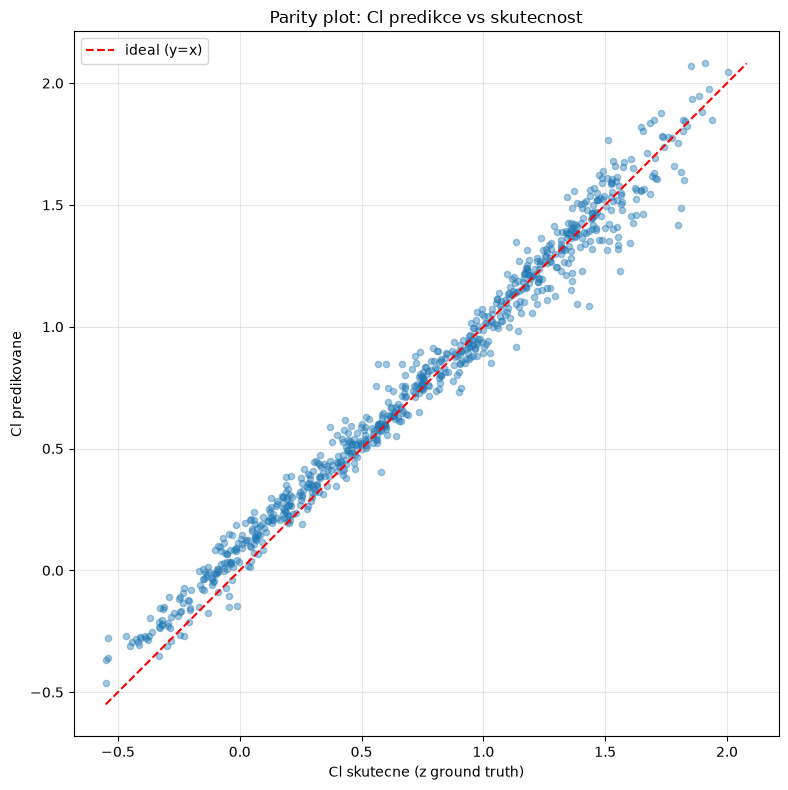

In [7]:
cl_true_all = []
cl_pred_all = []
for idx in range(len(preds_phys)):
    angle = X_phys[idx, 1, 0, 0]
    vel = X_phys[idx, 2, 0, 0]
    cl_true_all.append(compute_cl_from_grid(targets_phys[idx, 0], sdf_all[idx], angle, vel))
    cl_pred_all.append(compute_cl_from_grid(preds_phys[idx, 0], sdf_all[idx], angle, vel))

cl_true_all = np.array(cl_true_all)
cl_pred_all = np.array(cl_pred_all)

# Parity plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(cl_true_all, cl_pred_all, alpha=0.4, s=20)
lims = [min(cl_true_all.min(), cl_pred_all.min()),
        max(cl_true_all.max(), cl_pred_all.max())]
ax.plot(lims, lims, "r--", label="ideal (y=x)")
ax.set_xlabel("Cl skutecne (z ground truth)")
ax.set_ylabel("Cl predikovane")
ax.set_title("Parity plot: Cl predikce vs skutecnost")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 8. Spearman korelace — řadí model profily správně?

**Tohle je klíčová metrika pro design.** Pro optimalizaci airfoilů často nepotřebuješ
přesnou hodnotu Cl — potřebuješ vědět **který profil má větší vztlak než druhý**.

Spearman korelace měří jak dobře model zachovává POŘADÍ. 1.0 = perfektní pořadí.

In [9]:
rho_cl, p_value = spearmanr(cl_true_all, cl_pred_all)
pearson_cl = np.corrcoef(cl_true_all, cl_pred_all)[0, 1]

print(f"Spearman korelace Cl: {rho_cl:.4f}")
print(f"Pearson korelace Cl:  {pearson_cl:.4f}")
print()
if rho_cl > 0.95:
    print("VYBORNE - model radi profily podle vztlaku temer dokonale")
elif rho_cl > 0.85:
    print("DOBRE - model dobre zachycuje trend vztlaku")
elif rho_cl > 0.7:
    print("OK - trend je zachycen, ale s chybami")
else:
    print("SLABE - model nezachycuje poradi spolehlive")

# Mean relative error
mask_nonzero = np.abs(cl_true_all) > 0.01
rel_err = np.mean(np.abs((cl_pred_all[mask_nonzero] - cl_true_all[mask_nonzero])
                          / cl_true_all[mask_nonzero])) * 100
print(f"\nPrumerna relativni chyba Cl: {rel_err:.1f}%")

Spearman korelace Cl: 0.9924
Pearson korelace Cl:  0.9911

VYBORNE - model radi profily podle vztlaku temer dokonale

Prumerna relativni chyba Cl: 34.9%


## 9. Error analýza — kde model selhává?

Podíváme se jestli chyba koreluje s úhlem náběhu nebo tloušťkou profilu.
Tohle je nejcennější insight do projektu — pochopení LIMITŮ modelu.

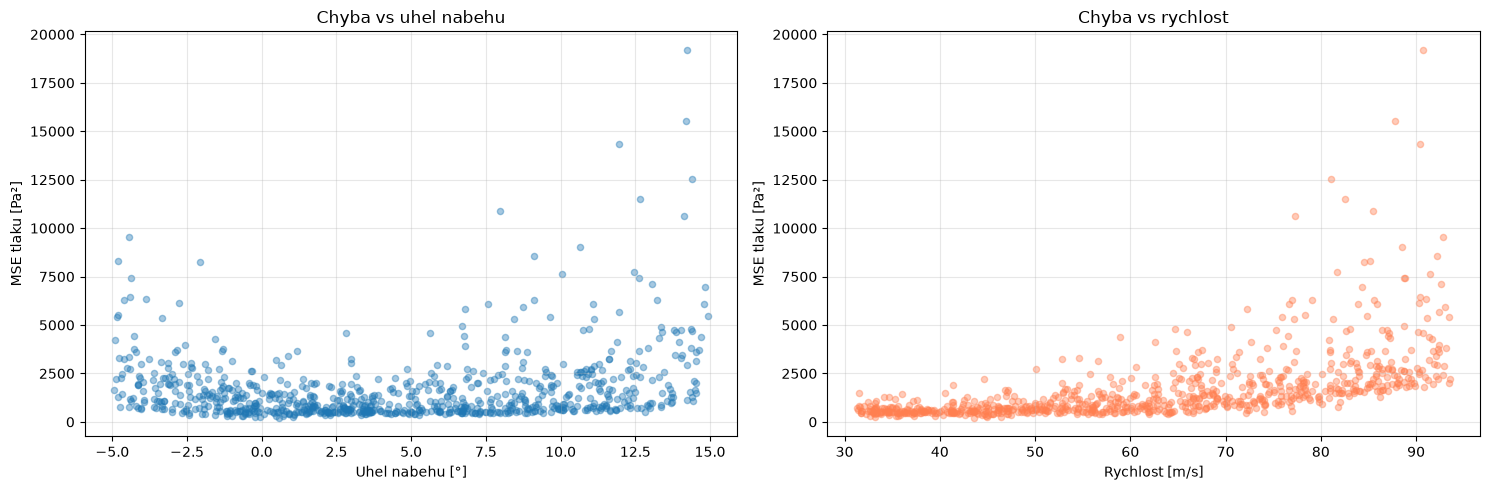

Korelace chyby s uhlem nabehu: 0.317
Korelace chyby s rychlosti:    0.565

Vyssi rychlost casto = vetsi tlaky = vetsi absolutni chyba (ocekavane).


In [10]:
# Chyba na vzorek (MSE v poli tlaku)
per_sample_err = np.mean((preds_phys[:, 0] - targets_phys[:, 0])**2, axis=(1, 2))

# Uhly nabehu vsech vzorku
angles_deg = np.degrees(X_phys[:, 1, 0, 0])
velocities = X_phys[:, 2, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(angles_deg, per_sample_err, alpha=0.4, s=20)
axes[0].set_xlabel("Uhel nabehu [°]")
axes[0].set_ylabel("MSE tlaku [Pa²]")
axes[0].set_title("Chyba vs uhel nabehu")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(velocities, per_sample_err, alpha=0.4, s=20, color="coral")
axes[1].set_xlabel("Rychlost [m/s]")
axes[1].set_ylabel("MSE tlaku [Pa²]")
axes[1].set_title("Chyba vs rychlost")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Korelace
print(f"Korelace chyby s uhlem nabehu: {np.corrcoef(np.abs(angles_deg), per_sample_err)[0,1]:.3f}")
print(f"Korelace chyby s rychlosti:    {np.corrcoef(velocities, per_sample_err)[0,1]:.3f}")
print("\nVyssi rychlost casto = vetsi tlaky = vetsi absolutni chyba (ocekavane).")

## 10. OOD experiment — co se stane s ne-airfoilem?

**Tohle je klíčová demonstrace pro portfolio.** Model se učil JEN na hladkých
airfoilech. Co udělá s trojúhelníkem nebo čtvercem?

Vyrobíme jednoduché geometrické tvary, převedeme na SDF, pošleme skrz model
a uvidíme že predikce je **fyzikální nesmysl** — protože tvar je mimo trénovací
distribuci.

In [11]:
from scipy.ndimage import distance_transform_edt

def make_shape_sdf(shape="triangle", grid_size=128):
    """Vytvori masku tvaru a spocita SDF, ve stejnem formatu jako trenovaci data."""
    mask = np.zeros((grid_size, grid_size), dtype=bool)

    # Stred profilu byva kolem x=0..1 (v domene -1..3) -> pixely ~32..64
    # y kolem 0 (v domene -1.5..1.5) -> pixely ~64
    cx, cy = 48, 64   # stred tvaru v pixelech
    size = 18

    yy, xx = np.mgrid[0:grid_size, 0:grid_size]

    if shape == "triangle":
        # Trojuhelnik
        for i in range(grid_size):
            for j in range(grid_size):
                dx = j - cx
                dy = i - cy
                if -size < dx < size and abs(dy) < (size - abs(dx)) * 0.6:
                    mask[i, j] = True
    elif shape == "square":
        mask[(cy-12):(cy+12), (cx-size):(cx+size)] = True
    elif shape == "circle":
        mask = ((xx - cx)**2 + (yy - cy)**2) < (size*0.7)**2

    # SDF: vzdalenost od tvaru (vne kladna)
    sdf = distance_transform_edt(~mask).astype(np.float32)
    # Skalovani aby odpovidalo trenovacim datum (priblizne)
    sdf = sdf * (4.0 / grid_size)
    return sdf, mask


def predict_shape(sdf, angle_deg=5, velocity=50):
    """Sestavi vstup a pusti skrz model."""
    angle_rad = np.radians(angle_deg)
    # Normalizace vstupu (stejne jako trenink)
    inp = np.stack([
        sdf,
        np.full((128, 128), angle_rad, dtype=np.float32),
        np.full((128, 128), float(velocity), dtype=np.float32),
    ])
    inp_norm = (inp - X_mean[0]) / (X_std[0] + 1e-8)
    inp_t = torch.from_numpy(inp_norm[None].astype(np.float32)).to(device)

    with torch.no_grad():
        pred_norm = model(inp_t).cpu().numpy()[0]
    pred_phys = pred_norm * Y_std[0] + Y_mean[0]
    return pred_phys

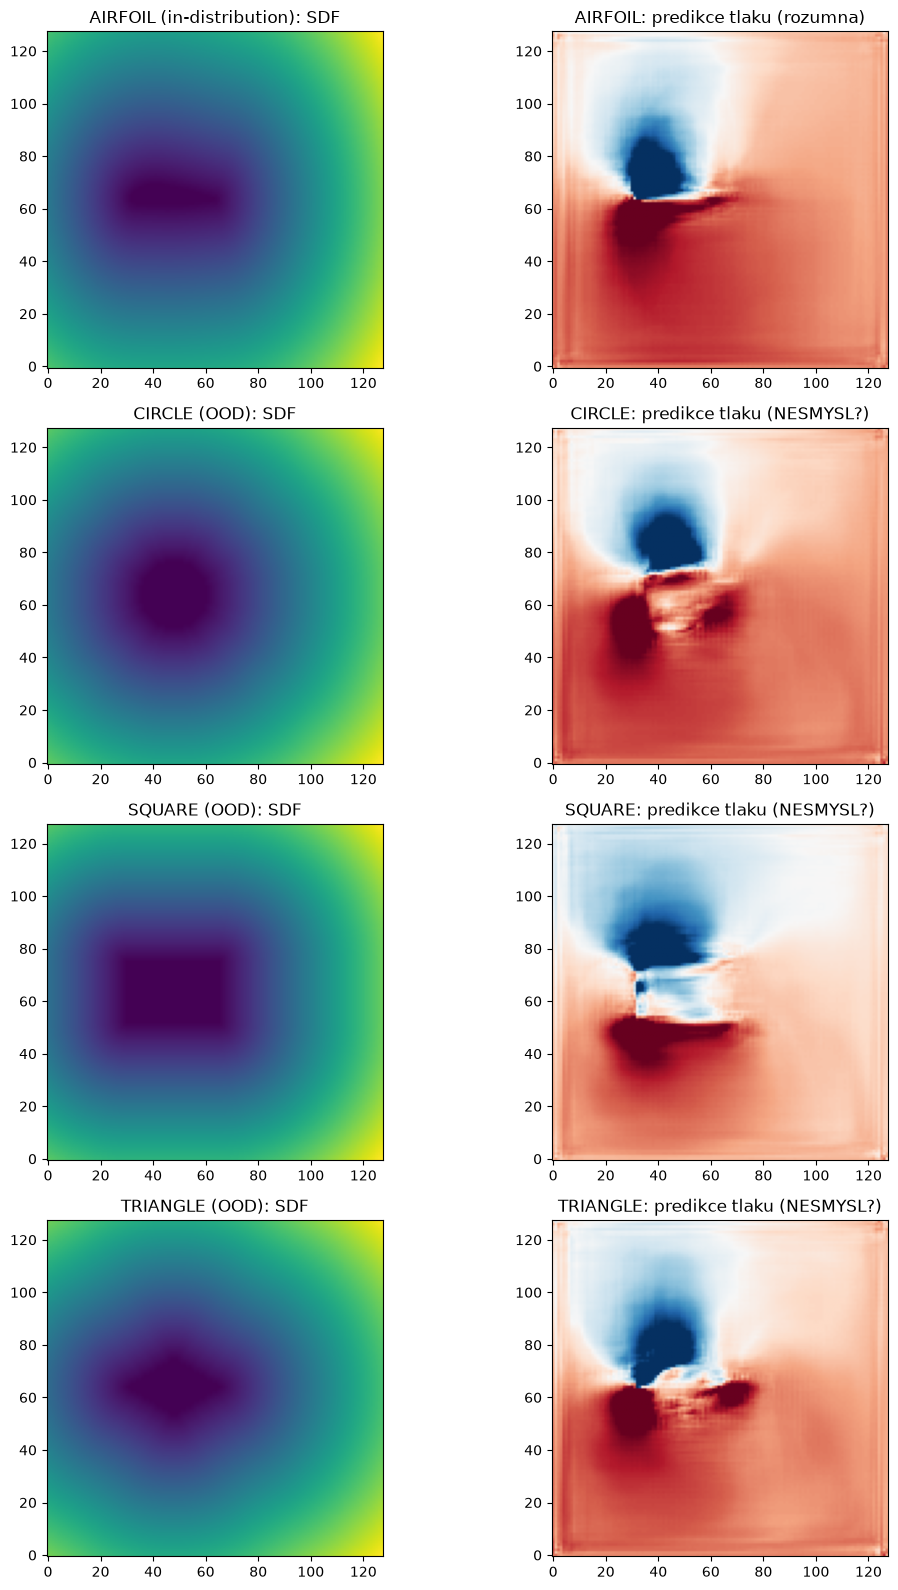

Porovnej: airfoil dava fyzikalne rozumnou predikci.
OOD tvary (kruh, ctverec, trojuhelnik) - model 'halucinuje' airfoil-like
vzor i tam kde fyzikalne nedava smysl, protoze takove tvary nikdy nevidel.


In [12]:
# Vyzkousime tri OOD tvary + porovname s realnym airfoilem
shapes = ["circle", "square", "triangle"]
fig, axes = plt.subplots(len(shapes) + 1, 2, figsize=(11, 16))

# Realny airfoil (reference) - prvni radek
ax = axes[0, 0]
ax.imshow(sdf_all[0], cmap="viridis", origin="lower")
ax.set_title("AIRFOIL (in-distribution): SDF")
ax = axes[0, 1]
vmin, vmax = np.percentile(preds_phys[0, 0], [2, 98])
ax.imshow(preds_phys[0, 0], cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax)
ax.set_title("AIRFOIL: predikce tlaku (rozumna)")

# OOD tvary
for row, shape in enumerate(shapes, start=1):
    sdf, mask = make_shape_sdf(shape)
    pred = predict_shape(sdf, angle_deg=5, velocity=50)

    axes[row, 0].imshow(sdf, cmap="viridis", origin="lower")
    axes[row, 0].set_title(f"{shape.upper()} (OOD): SDF")

    vmin, vmax = np.percentile(pred[0], [2, 98])
    axes[row, 1].imshow(pred[0], cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"{shape.upper()}: predikce tlaku (NESMYSL?)")

plt.tight_layout()
plt.show()
print("Porovnej: airfoil dava fyzikalne rozumnou predikci.")
print("OOD tvary (kruh, ctverec, trojuhelnik) - model 'halucinuje' airfoil-like")
print("vzor i tam kde fyzikalne nedava smysl, protoze takove tvary nikdy nevidel.")

## 11. Diskuse výsledků (pro portfolio)

**Shrnutí co jsi zjistil — tohle patří do README:**

**Co model umí dobře:**
- Predikce tlakového a rychlostního pole pro NACA profily (R² viz buňka 4)
- Zachování pořadí vztlaku (Spearman viz buňka 8) — užitečné pro design/optimalizaci
- ~1000× rychlejší než původní CFD simulace

**Známá omezení (a PROČ):**
1. **Chyba u povrchu** — U-Net vyhlazuje ostré gradienty u náběžné hrany
   (suction peak). Surface metriky horší než volume.
2. **Cd nelze spolehlivě spočítat** — závisí na wall shear stress (gradienty
   rychlosti u stěny), které hrubý 128×128 grid nezachytí. Proto se zaměřujeme na Cl.
3. **Out-of-distribution selhání** — model na ne-airfoilech (trojúhelník, čtverec)
   produkuje nesmysl, protože extrapoluje mimo trénovací distribuci. To NENÍ bug,
   ale fundamentální vlastnost ML modelů. Demonstruje důležitost znalosti limitů.

**Možná vylepšení (future work):**
- Víc epoch (loss ještě klesal)
- Vyšší rozlišení (256×256) — máš dost VRAM
- Outlier clipping na extrémní tlaky před normalizací
- Physics-informed loss (respektování Navier-Stokes)
- Uncertainty estimation (model by řekl "tomuhle tvaru nerozumím")
- OOD detekce (varování když je vstup mimo distribuci)

---

**Commitni výsledky:**
```
git add notebooks/04_evaluate.ipynb
git commit -m "Add notebook 04: evaluation, Cl, Spearman, OOD experiment"
git push
```

**Co dál:** Streamlit demo (app.py) — zabalíme model do interaktivní webové aplikace!